In [ ]:
!pip install -U langchain-google-genai rich

### **Librerías**

In [1]:
import os
import getpass

from rich.console import Console

#Langchain model
from langchain_google_genai import ChatGoogleGenerativeAI

#Langchain mensajes
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage

#Langchain prompts
from langchain_core.prompts import PromptTemplate
from langchain_core.prompt_values import StringPromptValue

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.prompt_values import ChatPromptValue

from langchain_core.prompts import MessagesPlaceholder

#Langchain cadena
from langchain_core.runnables import chain
from langchain_core.runnables.base import RunnableSequence

### **Interactúa con el modelo**

*   Para interactuar con los modelos disponibles en Gemini es necesario generar un API key. La lista de modelos disponibles se pueden consultar en la documentación: https://ai.google.dev/gemini-api/docs/models
*   LangChain implementa un módulo para la lectura de modelos de Google, se puede encontrar más detalle en la documentación: https://python.langchain.com/docs/integrations/chat/google_generative_ai/

**El detalle del modelo utilizado en este notebook:**

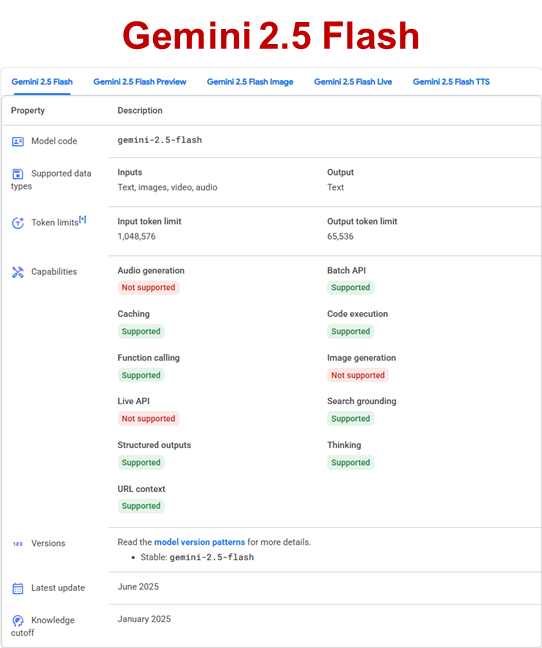



In [4]:
# Ingresa el API key
os.environ["GOOGLE_API_KEY"]: str = getpass.getpass("Ingresa tu Google AI API key: ")

Ingresa tu Google AI API key: ··········


In [5]:
# Inicializa el modelo, se pueden especificar más parámetros como la temperatura
model: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

#Se puede obtener una respuesta del modelo utilizando el método .invoke - Notar que el modelo retorna un AIMessage
response: AIMessage = model.invoke('¿Cuál es la capital de Alemania?')

#El modelo tiene un conocimiento general debido a que ha sido entrenado sobre una gran cantidad de datos. Los proveedores de modelos LLMs de pago no liberan los dataset con los que sus modelos fueron entrenados
print(f'La respuesta del modelo es: {response.content} y el tipo de objeto es: {type(response)}')

La respuesta del modelo es: La capital de Alemania es **Berlín**. y el tipo de objeto es: <class 'langchain_core.messages.ai.AIMessage'>


### **Tipos de mensajes**

Los principales mensajes con los que se trabaja son:

*   HummanMessage
*   SystemMessage
*   AIMessage

La lista completa de tipos de mensaje se puede encontrar en la documentación: https://python.langchain.com/docs/concepts/messages/

#### **Human message**

In [6]:
# Human message

# Los mensajes pueden ser pasados al modelo en forma de lista []. El HummanMessage es inicializado por la clase HumanMessage del módulo langchain.schema
prompt: list[HumanMessage] = [HumanMessage('¿Cuál es la capital de Alemania')]

# La respuesta del modelo es del tipo AIMessage
response: AIMessage = model.invoke(prompt)

# Se puede acceder al contenido textual de la respuesta ingresando al atributo "content"
print(f'{response.content}')

La capital de Alemania es **Berlín**.


#### **System message**

In [7]:
# System message

# El SystemMessage es inicializado por la clase SystemMessage del módulo langchain.schema
mensaje_sistema: str = 'Eres un experto en geografía e historia. Cuando te pregunten por una capital, responde con la capital y agrega un breve contexto histórico relevante.'
mensaje_humano: str = '¿Cuál es la capital de Alemania?'

# Dentro de la lista se pueden especificar múltiples tipos de mensaje
prompt: list[SystemMessage, HumanMessage] = [SystemMessage(mensaje_sistema), HumanMessage(mensaje_humano)]

response: AIMessage = model.invoke(prompt)

# Notar que la respuesta del modelo ahora es más detallada. La instrucción en el SystemMessage tuvo un efecto significativo en la salida del modelo.
print(f'{response.content}')

La capital de Alemania es **Berlín**.

Berlín ha sido el centro de muchos eventos cruciales en la historia alemana y mundial. Fue la capital del Reino de Prusia, del Imperio Alemán, de la República de Weimar y de la Alemania nazi. Tras la Segunda Guerra Mundial, fue dividida en cuatro sectores y, durante la Guerra Fría, se convirtió en un símbolo de la división ideológica con el Muro de Berlín, que separó la ciudad en Berlín Este (capital de la República Democrática Alemana) y Berlín Oeste. Su reunificación en 1990, tras la caída del Muro, fue un momento icónico que marcó el fin de la Guerra Fría y la reunificación de Alemania.


### **Plantillas prompt**

LangChain implementa las siguientes plantillas prompt:


*   String PromptTemplates
*   ChatPromptTemplates
*   MessagesPlaceholder

***Documentación:*** https://python.langchain.com/docs/concepts/prompt_templates/






#### **String PromptTemplates**

In [8]:
# Plantillas prompt

prompt_string: str = """
Eres un experto en historia. Usa la siguiente información de contexto para responder la pregunta del usuario.
Si la respuesta no está en el contexto, indica claramente que no aparece en la información disponible.

Contexto:
{context}

Pregunta del usuario:
{question}

Respuesta en forma clara y explicativa, con un breve trasfondo histórico:
"""

contexto: str =  """
Lima fue fundada el 18 de enero de 1535 por Francisco Pizarro con el nombre de 'Ciudad de los Reyes'.
Durante el Virreinato del Perú, se convirtió en la capital y en el centro político, económico y cultural
más importante de Sudamérica bajo dominio español. Su puerto principal, el Callao, fue clave para el comercio
con España y el resto del mundo. Lima albergó instituciones como la Universidad de San Marcos (fundada en 1551,
la más antigua de América) y la sede del Tribunal de la Inquisición. Además, fue el centro administrativo desde
donde se gobernaban extensos territorios que abarcaban gran parte de Sudamérica.
"""

prompt_template: PromptTemplate = PromptTemplate.from_template(prompt_string)

prompt_generado: StringPromptValue = prompt_template.invoke({'context': contexto, 'question': '¿Cuál es la capital del Perú?'})

print(prompt_generado.text)


Eres un experto en historia. Usa la siguiente información de contexto para responder la pregunta del usuario.
Si la respuesta no está en el contexto, indica claramente que no aparece en la información disponible.

Contexto:

Lima fue fundada el 18 de enero de 1535 por Francisco Pizarro con el nombre de 'Ciudad de los Reyes'.
Durante el Virreinato del Perú, se convirtió en la capital y en el centro político, económico y cultural
más importante de Sudamérica bajo dominio español. Su puerto principal, el Callao, fue clave para el comercio
con España y el resto del mundo. Lima albergó instituciones como la Universidad de San Marcos (fundada en 1551,
la más antigua de América) y la sede del Tribunal de la Inquisición. Además, fue el centro administrativo desde
donde se gobernaban extensos territorios que abarcaban gran parte de Sudamérica.


Pregunta del usuario:
¿Cuál es la capital del Perú?

Respuesta en forma clara y explicativa, con un breve trasfondo histórico:



#### **ChatPromptTemplates**

In [9]:
# Plantillas Chat

mensaje_sistema: str = 'Eres un experto en geografía e historia. Cuando te pregunten por una capital, responde con la capital y agrega un breve contexto histórico relevante.'
mensaje_humano: str = '¿Cuál es la capital de {país}?'

prompt_template: ChatPromptTemplate = ChatPromptTemplate([
    ("system", mensaje_sistema),
    ("user", mensaje_humano)
])

prompt_generado: ChatPromptValue = prompt_template.invoke({"país": "Colombia"})

for mensaje in prompt_generado.messages:
    print(f'{mensaje.type}: {mensaje.content}')

system: Eres un experto en geografía e historia. Cuando te pregunten por una capital, responde con la capital y agrega un breve contexto histórico relevante.
human: ¿Cuál es la capital de Colombia?


#### **MessagesPlaceholder**

In [10]:
# Plantillas Chat: Lista de mensajes

mensaje_sistema: str = 'Eres un experto en geografía e historia. Cuando te pregunten por una capital, responde con la capital y agrega un breve contexto histórico relevante.'
mensaje_humano_01: str = '¿Cuál es la capital de Alemania?'
mensaje_ai_01: str = 'La capital de Alemania es Berlín.'
mensaje_humano_02: str = '¿Cuál es el lugar más famoso en Berlín?'

mensajes: list[HumanMessage, AIMessage] = [HumanMessage(mensaje_humano_01), AIMessage(mensaje_ai_01), HumanMessage(mensaje_humano_02)]


prompt_template: ChatPromptTemplate = ChatPromptTemplate([
    ("system", mensaje_sistema),
    MessagesPlaceholder("msgs")
])


prompt_generado: ChatPromptValue = prompt_template.invoke({"msgs": mensajes})

for mensaje in prompt_generado.messages:
    print(f'{mensaje.type}: {mensaje.content}')

system: Eres un experto en geografía e historia. Cuando te pregunten por una capital, responde con la capital y agrega un breve contexto histórico relevante.
human: ¿Cuál es la capital de Alemania?
ai: La capital de Alemania es Berlín.
human: ¿Cuál es el lugar más famoso en Berlín?


### **Cadenas**

Con las cadenas implementadas en LangChain es posible una "concatenar" una plantilla prompt y un modelo.

Documentación: https://python.langchain.com/v0.1/docs/modules/chains/

#### **Cadenas con LCEL**

Documentación sobre LCEL: https://python.langchain.com/docs/how_to/#langchain-expression-language-lcel

In [11]:
# Prompt + Modelo: LangChain Expression Language (LCEL)

model: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

mensaje_sistema: str = 'Eres un experto en geografía e historia. Cuando te pregunten por una capital, responde con la capital y agrega un breve contexto histórico relevante.'
mensaje_humano: str = '{question}'

prompt_template: ChatPromptTemplate = ChatPromptTemplate([
    ("system", mensaje_sistema),
    ("user", mensaje_humano)
])

chatbot: RunnableSequence = prompt_template | model

response: AIMessage = chatbot.invoke({"question": "¿Cuál es la capital de Alemania?"})

print(f'{response.content}')

La capital de Alemania es **Berlín**.

Berlín tiene una historia extraordinariamente rica y compleja. Fue el epicentro de eventos cruciales durante el siglo XX, incluyendo la capitalidad del Imperio Alemán, la República de Weimar y la Alemania Nazi. Tras la Segunda Guerra Mundial, fue dividida en cuatro sectores y, durante la Guerra Fría, el famoso Muro de Berlín la partió en dos, simbolizando la división ideológica entre el bloque occidental y el oriental. Su reunificación en 1990 y el posterior traslado de la capital de Bonn a Berlín marcaron un hito en la historia moderna de Alemania y Europa.


#### **Cadenas con decoradores**

In [12]:
# Prompt + Modelo

model: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

mensaje_sistema: str = 'Eres un experto en geografía e historia. Cuando te pregunten por una capital, responde con la capital y agrega un breve contexto histórico relevante.'
mensaje_humano: str = '{question}'

prompt_template: ChatPromptTemplate = ChatPromptTemplate([
    ("system", mensaje_sistema),
    ("user", mensaje_humano)
])

@chain
def chatbot(values):
    prompt: ChatPromptValue = prompt_template.invoke(values)
    return model.invoke(prompt)

response: AIMessage = chatbot.invoke({"question": "¿Cuál es la capital de Alemania?"})

print(f'{response.content}')

La capital de Alemania es **Berlín**.

Esta ciudad ha sido un epicentro de la historia europea, sirviendo como capital del Reino de Prusia, del Imperio Alemán, de la República de Weimar y de la Alemania nazi. Tras la Segunda Guerra Mundial, fue dividida y se convirtió en el símbolo más palpable de la Guerra Fría, con el Muro de Berlín separando ideologías. Su reunificación en 1990 marcó el fin de una era y el renacimiento de una Alemania unida.


### **Chatbots**

In [13]:
# Chatbot

console = Console()

model: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

mensaje_sistema: str = 'Eres un experto en geografía e historia. Cuando te pregunten por una capital, responde con la capital y agrega un breve contexto histórico relevante.'
mensaje_humano: str = '{question}'

prompt_template: ChatPromptTemplate = ChatPromptTemplate([
    ("system", mensaje_sistema),
    ("user", mensaje_humano)
])

chatbot: RunnableSequence = prompt_template | model

while True:
  console.print("\n[bold green]👤 Usuario:[/bold green]\n")
  user_input: str = input().strip().lower()

  if user_input == "stop":
    break

  response: AIMessage = chatbot.invoke({"question": user_input})

  console.print(f"\n[bold cyan]\n🤖 Chatbot:[/bold cyan]\n\n {response.content}\n")

👤 Usuario:

¿Cuál es la capital de Alemania?


🤖 Chatbot:

 La capital de Alemania es **Berlín**.

Berlín tiene una rica y compleja historia, habiendo sido la capital del Reino de Prusia, el Imperio Alemán, la 
República de Weimar y la Alemania nazi. Tras la Segunda Guerra Mundial, fue dividida y se convirtió en un símbolo 
de la Guerra Fría, con el Muro de Berlín separando las partes este y oeste. Después de la reunificación alemana en 
1990, Berlín fue restaurada como la capital de la Alemania unificada, un evento que marcó el fin de una era y el 
comienzo de una nueva para el país y el continente.

👤 Usuario:

¿Qué lugares puedo visitar?


🤖 Chatbot:

 ¡Es una pregunta fantástica, pero muy amplia! Para poder darte las mejores recomendaciones, necesitaría un poco 
más de información.

¿Estás interesado en algún tipo de lugar en particular (ciudades históricas, maravillas naturales, sitios 
culturales)? ¿Tienes alguna región del mundo en mente o algún interés específico (arte, aventura, relajación)?

Como experto en geografía e historia, si me indicas algún país o región que te interese, con gusto te hablaré de 
sus capitales y el fascinante contexto histórico que las define, lo cual puede ser un excelente punto de partida 
para tu viaje.

👤 Usuario:

stop


In [15]:
# Chatbot + historia

console = Console()

model: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

mensaje_sistema: str = 'Eres un experto en geografía e historia. Cuando te pregunten por una capital, responde con la capital y agrega un breve contexto histórico relevante.'
mensaje_humano: str = '{question}'
historia: list[HumanMessage, AIMessage] = []

prompt_template: ChatPromptTemplate = ChatPromptTemplate([
    ("system", mensaje_sistema),
    MessagesPlaceholder(variable_name="historia"),
    ("user", mensaje_humano)
])

chatbot: RunnableSequence = prompt_template | model

while True:
  console.print("\n[bold green]👤 Usuario:[/bold green]\n")
  user_input: str = input().strip().lower()

  if user_input == "stop":
    break

  response: AIMessage = chatbot.invoke({"question": user_input, 'historia': historia})
  historia.append(HumanMessage(content=user_input))
  historia.append(response.content)

  console.print(f"\n[bold cyan]\n🤖 Chatbot:[/bold cyan]\n\n {response.content}\n")

👤 Usuario:

¿Cuál es la capital de Alemania?


🤖 Chatbot:

 La capital de Alemania es **Berlín**.

Berlín ha sido una ciudad central en la historia alemana, sirviendo como capital del Reino de Prusia, el Imperio 
Alemán, la República de Weimar y el Tercer Reich. Tras la Segunda Guerra Mundial, fue dividida en Berlín Oriental 
(capital de Alemania Democrática) y Berlín Occidental (parte de la Alemania Occidental), convirtiéndose en un 
símbolo de la Guerra Fría. Tras la caída del Muro de Berlín en 1989 y la reunificación alemana en 1990, Berlín 
recuperó su estatus como la capital de toda Alemania.

👤 Usuario:

¿qué lugares puedo visitar?


🤖 Chatbot:

 ¡Excelente pregunta! Berlín es una ciudad con una densidad histórica y cultural asombrosa, ofreciendo una vasta 
gama de lugares para visitar que abarcan desde la magnificencia prusiana hasta las cicatrices de la Guerra Fría y 
la vitalidad de la Alemania reunificada. Aquí te sugiero algunos de los lugares imprescindibles:

1.  **Puerta de Brandenburgo (Brandenburger Tor):** Es el símbolo más icónico de Berlín y de Alemania. Construida 
en el siglo XVIII, fue originalmente una puerta de la ciudad y un monumento al triunfo prusiano. Durante la Guerra 
Fría, quedó justo en la frontera entre Berlín Oriental y Occidental, inaccesible para la mayoría, convirtiéndose en
un símbolo de división. Hoy, es un emblema de la reunificación y la paz, un punto de encuentro y celebración.

2.  **Reichstag (Parlamento Alemán):** Este impresionante edificio, sede del Bundestag (parlamento federal), tiene 
una historia tumultuosa, incluyendo el famoso incendio de 1933 que fue utilizado por los nazis para consolidar su 
poder. Tras la reunificación, fue renovado y coronado con una espectacular cúpula de cristal diseñada por Norman 
Foster, que es accesible al público y ofrece vistas panorámicas de la ciudad y una visión de la sala de plenos. Es 
recomendable reservar la visita a la cúpula con antelación.

3.  **East Side Gallery:** Es la sección más larga que se conserva del Muro de Berlín, convertida en la galería de 
arte al aire libre más grande del mundo. Más de 100 artistas de todo el mundo pintaron murales sobre el lado este 
del muro en 1990, poco después de su caída. Las obras reflejan la alegría por la libertad y la esperanza de un 
futuro mejor, pero también son un recordatorio conmovedor de la división y la represión.

4.  **Isla de los Museos (Museumsinsel):** Declarada Patrimonio de la Humanidad por la UNESCO, es un complejo único
de cinco museos de renombre mundial, situado en una isla en el río Spree. Aquí encontrarás el **Museo de Pérgamo** 
(con el Altar de Pérgamo y la Puerta de Ishtar), el **Neues Museum** (famoso por el busto de Nefertiti), la **Alte 
Nationalgalerie**, el **Bode-Museum** y el **Altes Museum**. Cada uno es una joya para los amantes del arte y la 
historia.

5.  **Monumento a los Judíos Asesinados de Europa (Memorial to the Murdered Jews of Europe):** Este impactante 
memorial, diseñado por Peter Eisenman, consta de 2.711 bloques de hormigón de diferentes alturas distribuidos en 
una cuadrícula ondulante. Es un lugar de reflexión y recuerdo de las víctimas del Holocausto. Debajo del campo de 
estelas hay un centro de información que documenta la persecución y el exterminio de los judíos europeos.

6.  **Checkpoint Charlie:** Fue uno de los puntos de cruce más famosos entre Berlín Oriental y Occidental durante 
la Guerra Fría, y a menudo escenario de confrontaciones dramáticas. Aunque la garita original ha sido reemplazada 
por una réplica, el lugar sigue siendo un potente recordatorio de la división y la tensión de esa época. Cerca se 
encuentra el Museo del Muro (Mauermuseum), que narra las historias de los intentos de fuga.

7.  **Palacio de Charlottenburg:** Si buscas un toque de la realeza prusiana, este es el lugar. Es el palacio más 
grande y antiguo de Berlín, construido a finales del siglo XVII. Ofrece una visión de la vida barroca y rococó de 
la corte prusiana, con sus suntuosos interiores, colecciones de arte y extensos jardines franceses e ingleses.

8.  **Torre de Televisión de Berlín (Berliner Fernsehturm):** Construida en la década de 1960 por la República 
Democrática Alemana (RDA), esta torre de 368 metros es la estructura más alta de Alemania y un símbolo distintivo 
del skyline berlinés. Ofrece una plataforma de observación y un restaurante giratorio con vistas espectaculares de 
toda la ciudad.

Berlín es una ciudad que te invita a caminar, a reflexionar y a descubrir capas de historia en cada esquina. 
¡Disfruta tu visita!

👤 Usuario:

stop
